In [1]:
# Load and join data
import pandas as pd

from mlops_air_quality_forecast.config import settings
from mlops_air_quality_forecast.data import latest_snapshot_tag, load_snapshot

tag = latest_snapshot_tag()
no2, weather = load_snapshot(tag)

no2 = no2[no2["observed_at"] >= pd.Timestamp(settings.training_start, tz="UTC")]
weather = weather[weather["source"] == "archive"]
df = no2.merge(weather, on="observed_at", how="inner").dropna(subset=["value_ugm3"])

local = df["observed_at"].dt.tz_convert("Europe/Copenhagen")
df["hour"] = local.dt.hour
df["weekday"] = local.dt.dayofweek
df["month"] = local.dt.month
df["is_weekend"] = df["weekday"] >= 5
print(tag, df.shape)

/home/jibran/ds-portfolio/mlops-air-quality-forecast/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


snapshot-20261002-1036 (39113, 17)


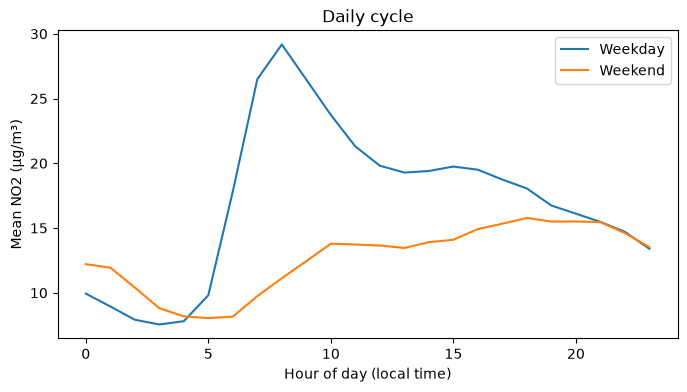

In [2]:
# Daily cycle

cycle = df.groupby(["hour", "is_weekend"])["value_ugm3"].mean().unstack()
ax = cycle.plot(figsize=(8, 4))
ax.set(
    xlabel="Hour of day (local time)", ylabel="Mean NO2 (µg/m³)", title="Daily cycle"
)
ax.legend(["Weekday", "Weekend"])

[Text(0.5, 0, 'Month'),
 Text(0, 0.5, 'Mean NO2 (µg/m³)'),
 Text(0.5, 1.0, 'Seasonal cycle')]

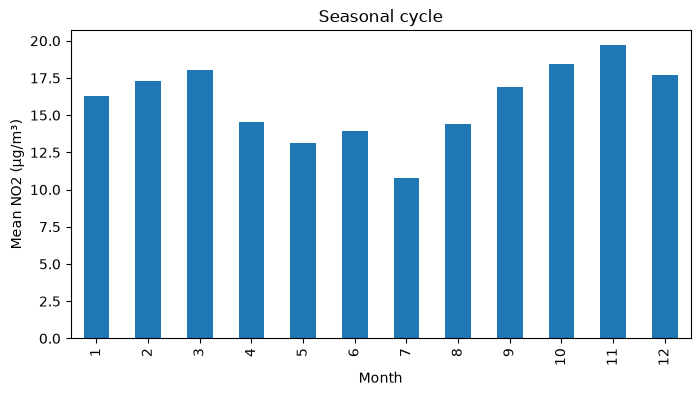

In [3]:
# Seasonal cycle

ax = df.groupby("month")["value_ugm3"].mean().plot(kind="bar", figsize=(8, 4))
ax.set(xlabel="Month", ylabel="Mean NO2 (µg/m³)", title="Seasonal cycle")

[Text(0.5, 0, 'Wind speed at 10 m (m/s)'),
 Text(0, 0.5, 'Mean NO2 (µg/m³)'),
 Text(0.5, 1.0, 'NO2 vs wind speed')]

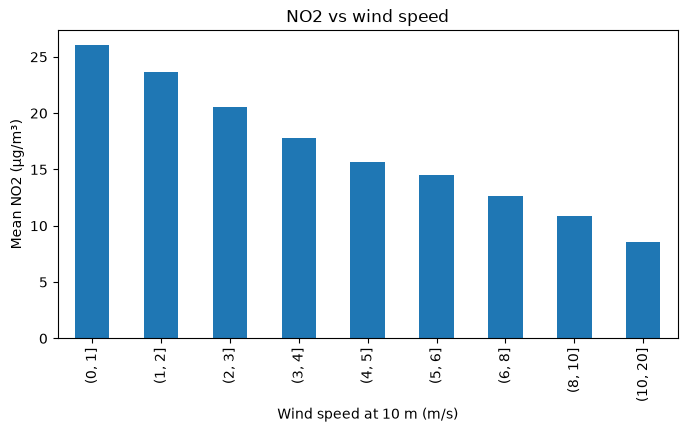

In [4]:
# Dilution by wind speed

bins = pd.cut(df["wind_speed_10m"], [0, 1, 2, 3, 4, 5, 6, 8, 10, 20])
ax = (
    df.groupby(bins, observed=True)["value_ugm3"]
    .mean()
    .plot(kind="bar", figsize=(8, 4))
)
ax.set(
    xlabel="Wind speed at 10 m (m/s)",
    ylabel="Mean NO2 (µg/m³)",
    title="NO2 vs wind speed",
)

[Text(0.5, 0, 'Boundary layer height (m, deciles)'),
 Text(0, 0.5, 'Mean NO2 (µg/m³)'),
 Text(0.5, 1.0, 'NO2 vs mixing height')]

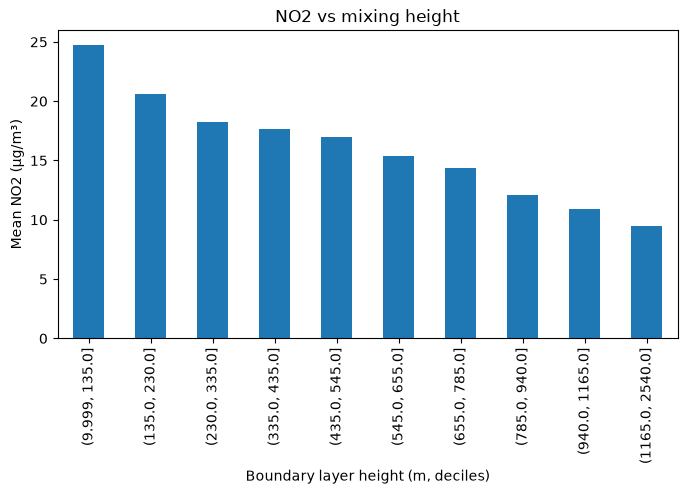

In [5]:
# Mixing by boundary layer height

bins = pd.qcut(df["boundary_layer_height"], 10)
ax = (
    df.groupby(bins, observed=True)["value_ugm3"]
    .mean()
    .plot(kind="bar", figsize=(8, 4))
)
ax.set(
    xlabel="Boundary layer height (m, deciles)",
    ylabel="Mean NO2 (µg/m³)",
    title="NO2 vs mixing height",
)

[Text(0.5, 0, 'Wind direction (degrees, 30° sectors)'),
 Text(0, 0.5, 'Mean NO2 (µg/m³)'),
 Text(0.5, 1.0, 'NO2 by wind direction')]

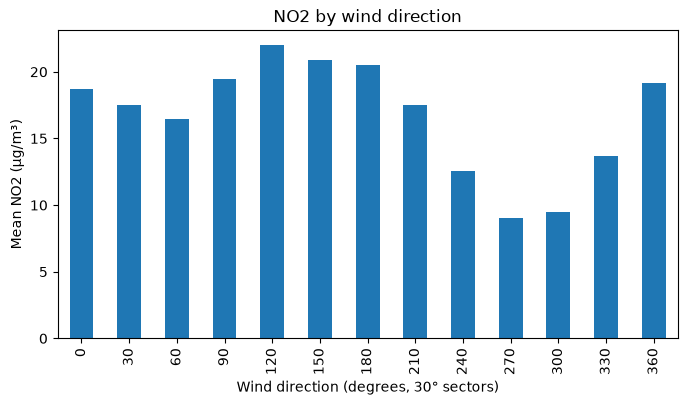

In [6]:
# wind direction

sectors = (df["wind_direction_10m"] // 30 * 30).astype(int)
ax = df.groupby(sectors)["value_ugm3"].mean().plot(kind="bar", figsize=(8, 4))
ax.set(
    xlabel="Wind direction (degrees, 30° sectors)",
    ylabel="Mean NO2 (µg/m³)",
    title="NO2 by wind direction",
)